# Análise e Teste de LSTM - Treinamento Local (v2 - Multiclasse D1)

Este notebook implementa o workflow de treinamento de uma LSTM multiclasse (0=BAIXA, 1=NEUTRO, 2=ALTA).

**Objetivo:** Após constatar que o timeframe H1 é muito ruidoso, esta versão foca em dados Diários (D1) para encontrar padrões mais significativos.

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import MetaTrader5 as mt5
from datetime import datetime, timedelta
import pytz
from IPython.display import display, HTML

from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

# Métricas para classificação
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotecas importadas com sucesso!")

# Inicializar MT5
if not mt5.initialize():
    print(f"Erro ao inicializar MT5: {mt5.last_error()}")
    raise Exception("Falha na inicialização do MetaTrader 5")

print(f"MT5 inicializado com sucesso!")
print(f"Versão: {mt5.version()}")

Bibliotecas importadas com sucesso!
MT5 inicializado com sucesso!
Versão: (500, 5430, '14 Nov 2025')


## 2. Parâmetros de Configuração

**MUDANÇA:** Foco no timeframe D1 (Diário) para reduzir o ruído.

In [2]:
# CÉLULA 2 (Substituir o conteúdo)

# Parâmetros do ativo e dados
TICKER = "WDO$"  # Contrato Futuro do Mini Dólar
timeframe_str = "M15"
START_DATE = datetime(2021, 1, 1) 
END_DATE = datetime(2025, 10, 31)
BUSCA_TICKS = False  # Habilitar coleta de dados de ticks

# Parâmetros da LSTM
LOOKBACK = 96         # Janela de lookback (N horas anteriores - 1 dia)
LSTM_UNITS = 64       # Unidades LSTM (Voltamos ao cérebro maior, pois teremos mais dados H1)
DROPOUT_RATE = 0.2    # Dropout
EPOCHS = 50           # Número de épocas
BATCH_SIZE = 128      # Tamanho do batch
TARGET_PERIOD = 5     # Período de previsão (N horas à frente)

# Parâmetros de divisão de dados
TEST_SIZE = 0.2       # 20% para teste
VALIDATION_SPLIT = 0.1 # 10% do treino para validação

# Timezone
TIMEZONE = pytz.timezone('Etc/UTC')

# Caminhos de Arquivo (Atualizados para H1)
# FILE_RAW = f"petr4_mt5_rates_{timeframe_str}_20230101_20241231_raw.csv"
# FILE_FEATURES = f"wdo$_{timeframe_str}_20230101_20241231_features.csv"
# FILE_CLEAN = f"wdo$_{timeframe_str}_20230101_20241231_clean.csv"

tp_map = { "M1": mt5.TIMEFRAME_M1, "M5": mt5.TIMEFRAME_M5, "M15": mt5.TIMEFRAME_M15,
                 "M30": mt5.TIMEFRAME_M30, "H1": mt5.TIMEFRAME_H1, "H4": mt5.TIMEFRAME_H4,
                 "D1": mt5.TIMEFRAME_D1, "W1": mt5.TIMEFRAME_W1, "MN1": mt5.TIMEFRAME_MN1 }

TIMEFRAME = tp_map.get(timeframe_str.upper(), mt5.TIMEFRAME_D1)

print(f"Configuração:")
print(f"  Ticker: {TICKER}")
print(f"  Período: {START_DATE.date()} a {END_DATE.date()}")
print(f"  Timeframe: {timeframe_str}")
print(f"  Lookback: {LOOKBACK}")
print(f"  LSTM Units: {LSTM_UNITS}")
print(f"  Dropout Rate: {DROPOUT_RATE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Target Period: {TARGET_PERIOD}")
print(f"  Test Size: {TEST_SIZE}")
print(f"  Validation Split: {VALIDATION_SPLIT}")

Configuração:
  Ticker: WDO$
  Período: 2021-01-01 a 2025-10-31
  Timeframe: M15
  Lookback: 96
  LSTM Units: 64
  Dropout Rate: 0.2
  Epochs: 50
  Batch Size: 128
  Target Period: 5
  Test Size: 0.2
  Validation Split: 0.1


## 3. Coleta de Dados

In [3]:
# --- FUNÇÃO DE DOWNLOAD EM LOTES ---
def download_rates_in_chunks(ticker, timeframe, start_dt, end_dt, chunk_size_days=365):
    """Baixa dados do MT5 em pedaços anuais para evitar limites."""
    rates_list = []
    current_start = start_dt.astimezone(pytz.UTC)
    final_end = end_dt.astimezone(pytz.UTC) + timedelta(hours=23, minutes=59)
    
    print(f"\nIniciando download em lotes de {chunk_size_days} dias...")
    
    while current_start < final_end:
        current_end = min(current_start + timedelta(days=chunk_size_days), final_end)
        
        print(f"  Baixando: {current_start.date()} até {current_end.date()} ...", end="")
        chunk = mt5.copy_rates_range(ticker, timeframe, current_start, current_end)
        
        if chunk is not None and len(chunk) > 0:
            rates_list.append(pd.DataFrame(chunk))
            print(f" OK ({len(chunk)} candles)")
        else:
            print(" Vazio ou Erro")
            
        # Avança para o próximo lote (sem pular tempo)
        current_start = current_end
        
    if not rates_list:
        return pd.DataFrame()
        
    # Concatena e remove duplicatas (caso haja sobreposição de milissegundos)
    df_final = pd.concat(rates_list).drop_duplicates(subset='time').reset_index(drop=True)
    return df_final

In [4]:
# --- 1. CONECTAR AO MT5 E COLETAR BARRAS (OHLCV) ---

if not mt5.initialize():
    print(f"Erro ao inicializar MT5: {mt5.last_error()}")
    raise Exception("Falha na inicialização do MetaTrader 5")

# Converter datas para UTC (MT5 trabalha em UTC)
start_date_utc = TIMEZONE.localize(START_DATE).astimezone(pytz.UTC)
end_date_utc = TIMEZONE.localize(END_DATE).astimezone(pytz.UTC)

print(f"\nBuscando dados de barras {TICKER} ({timeframe_str})...")
print(f"  Período UTC: {start_date_utc} a {end_date_utc}")

df_raw = download_rates_in_chunks(TICKER, TIMEFRAME, START_DATE, END_DATE)

if df_raw.empty:
    mt5.shutdown()
    raise Exception("Nenhum dado coletado!")

print(f"\n✓ {len(df_raw)} candles (barras) {timeframe_str} coletados com sucesso!")

# Ajustar DataFrame
df_raw['time'] = pd.to_datetime(df_raw['time'], unit='s', utc=True)
df_raw['time'] = df_raw['time'].dt.tz_convert(TIMEZONE)
df_raw.set_index('time', inplace=True)
df_raw.columns = ['open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
df_raw.rename(columns={'tick_volume': 'volume'}, inplace=True)

print(f"\n✓ Total acumulado: {len(df_raw)} candles de {timeframe_str}")
# --- 2. (NOVO) COLETAR DADOS DE TICKS PARA CADA BARRA ---

if BUSCA_TICKS:
    
    print(f"\nIniciando coleta de Ticks para cada uma das {len(df_raw)} barras (Isso pode demorar)...")

    imbalance_data = []
    total_ticks_processed = 0

    # Flags de agressão (Buy/Sell)
    FLAG_BUY = mt5.TICK_FLAG_BUY
    FLAG_SELL = mt5.TICK_FLAG_SELL

    # Iterar sobre cada barra H1 para buscar seus ticks
    # Usamos tqdm para a barra de progresso (opcional, mas recomendado)
    try:
        from tqdm.auto import tqdm
        iterator = tqdm(df_raw.iterrows(), total=len(df_raw), desc="Processando Ticks")
    except ImportError:
        print("Biblioteca tqdm não encontrada. Instalando... (pip install tqdm)")
        print("Re-execute esta célula após a instalação se a barra de progresso não aparecer.")
        iterator = df_raw.iterrows()


    for bar_time, bar in iterator:
        # Definir o início e o fim da janela de 1 hora para esta barra
        bar_start_utc = bar_time.astimezone(pytz.UTC)
        # O MT5 é inclusivo no final, então pegamos até 59m:59s
        bar_end_utc = bar_start_utc + timedelta(hours=1) - timedelta(seconds=1) 

        # Chamar copy_ticks_range para esta janela de 1 hora
        ticks = mt5.copy_ticks_range(TICKER, bar_start_utc, bar_end_utc, mt5.COPY_TICKS_TRADE)
        
        buy_volume = 0
        sell_volume = 0
        
        if ticks is not None and len(ticks) > 0:
            total_ticks_processed += len(ticks)
            
            # Converter para DataFrame para análise rápida
            df_ticks = pd.DataFrame(ticks)
            
            # Calcular volume de compra e venda baseado nos flags
            # Verificamos se o bit está "ligado" comparando com a própria flag ou verificando se é > 0
            buy_volume = df_ticks[(df_ticks['flags'] & FLAG_BUY) == FLAG_BUY]['volume'].sum()
            sell_volume = df_ticks[(df_ticks['flags'] & FLAG_SELL) == FLAG_SELL]['volume'].sum()

        # Saldo de Agressão (Volume Imbalance)
        volume_imbalance = buy_volume - sell_volume
        imbalance_data.append({
            'time': bar_time,
            'buy_volume': buy_volume,
            'sell_volume': sell_volume,
            'volume_imbalance': volume_imbalance
        })

    # --- 3. JUNTAR OS DADOS DE IMBALANCE AO DF_RAW ---

    df_imbalance = pd.DataFrame(imbalance_data).set_index('time')
    df_raw = df_raw.join(df_imbalance)

    # Preencher NaNs (se alguma barra não teve ticks, o imbalance será 0)
    df_raw[['buy_volume', 'sell_volume', 'volume_imbalance']] = df_raw[['buy_volume', 'sell_volume', 'volume_imbalance']].fillna(0)

    print(f"\n✓ Coleta de Ticks concluída. Total de Ticks processados: {total_ticks_processed}")
    print(f"\n✓ Feature 'volume_imbalance' adicionada ao df_raw.")


# Desligar MT5
mt5.shutdown()
print("\nMT5 desconectado.")

print(f"\nExemplo dos dados brutos coletados (últimas 5 linhas):")
display(df_raw.tail())


Buscando dados de barras WDO$ (M15)...
  Período UTC: 2021-01-01 00:00:00+00:00 a 2025-10-31 00:00:00+00:00

Iniciando download em lotes de 365 dias...
  Baixando: 2021-01-01 até 2022-01-01 ... OK (9042 candles)
  Baixando: 2022-01-01 até 2023-01-01 ... OK (9157 candles)
  Baixando: 2023-01-01 até 2024-01-01 ... OK (9083 candles)
  Baixando: 2024-01-01 até 2024-12-31 ... OK (9519 candles)
  Baixando: 2024-12-31 até 2025-11-01 ... OK (8003 candles)

✓ 44804 candles (barras) M15 coletados com sucesso!

✓ Total acumulado: 44804 candles de M15

MT5 desconectado.

Exemplo dos dados brutos coletados (últimas 5 linhas):


,open,high,low,close,volume,spread,real_volume
time,,,,,,,
2025-10-31 17:15:00+00:00,5412.5,5417.0,5412.0,5415.5,3093,1,18298
2025-10-31 17:30:00+00:00,5416.0,5417.0,5413.5,5415.5,2370,1,8831
2025-10-31 17:45:00+00:00,5415.5,5416.0,5410.5,5410.5,3623,1,17022
2025-10-31 18:00:00+00:00,5410.5,5412.5,5410.0,5410.5,1635,1,8481
2025-10-31 18:15:00+00:00,5410.5,5414.0,5409.0,5414.0,2144,1,11680


## 4. Análise de Volatilidade e Potencial de Target

Esta célula é nossa "bússola". Ela analisa o comportamento do ativo (agora em D1) e nos ajuda a definir uma "pergunta" (target) que seja justa e acessível para o assistente.

In [5]:
# CÉLULA 4.5 - ANÁLISE DE VOLATILIDADE FUTURA (PREPARAÇÃO PARA O NOVO TARGET)
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_true_range(df):
    """Calcula o True Range (TR)."""
    df_temp = df.copy()
    df_temp['high-low'] = df_temp['high'] - df_temp['low']
    df_temp['high-prev_close'] = np.abs(df_temp['high'] - df_temp['close'].shift(1))
    df_temp['low-prev_close'] = np.abs(df_temp['low'] - df_temp['close'].shift(1))
    df_temp['true_range'] = df_temp[['high-low', 'high-prev_close', 'low-prev_close']].max(axis=1)
    df.drop(columns=['high-low', 'high-prev_close', 'low-prev_close'], inplace=True, errors='ignore')
    return df_temp['true_range']

def analisar_volatilidade_futura(df_raw, atr_period=14, max_horizon=10):
    print("--- Analisando Potencial de Volatilidade (Explosão) ---")
    df = df_raw.copy()
    
    # 1. ATR Atual (O "Ruído" normal)
    df['true_range'] = calculate_true_range(df)
    df['atr'] = df['true_range'].rolling(window=atr_period).mean()
    df.dropna(inplace=True)
    
    # 2. Calcular a Amplitude Futura (Max High - Min Low nos próximos N candles)
    # Isso nos diz o quanto o preço "andou" no total, independente da direção
    results = []
    
    for period in [3, 5, 8]: # Horizontes de teste
        # Rolling Max High futuro e Min Low futuro (invertidos com shift para olhar para frente)
        # O shift negativo traz o futuro para o presente.
        # Usamos rolling reverso (manobra com indexação) ou simplesmente aproximamos:
        
        # Maneira eficiente: High máximo das próximas 'period' barras
        indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=period)
        future_high_max = df['high'].rolling(window=indexer).max()
        future_low_min = df['low'].rolling(window=indexer).min()
        
        # Amplitude (Range) Futura
        df[f'range_{period}'] = future_high_max - future_low_min
        
        # Normalizar pelo ATR atual (Quantas vezes o ATR o preço andou?)
        df[f'range_norm_{period}'] = df[f'range_{period}'] / df['atr']
        
        # Estatísticas
        desc = df[f'range_norm_{period}'].describe(percentiles=[.5, .75, .85, .90, .95])
        results.append({
            'Horizonte': f"{period} candles de {timeframe_str}",
            'Média (xATR)': desc['mean'],
            'Mediana (xATR)': desc['50%'],
            'Top 25% (xATR)': desc['75%'], # Um bom candidato a "Explosão"
            'Top 15% (xATR)': desc['85%'], # Explosão muito forte
        })
        
    df_results = pd.DataFrame(results).set_index('Horizonte')
    
    print("\n📊 QUANTO O PREÇO 'ANDA' (EM xATR) NO FUTURO?")
    print("   (Ex: 2.5 significa que o preço oscilou 2.5x o ATR normal naquele período)")
    display(df_results.style.format("{:.2f}x ATR"))
    
    # Descobrimos a chave correta dinamicamente
    chave_5_periodos = f"5 candles de {timeframe_str}" # Ex: "5 candles de M15"
    
    print("\n💡 SUGESTÃO DE TARGET:")
    try:
        limiar_sugerido = df_results.loc[chave_5_periodos, 'Top 25% (xATR)']
        print(f"   Para capturar as 25% maiores movimentações em {chave_5_periodos}:")
        print(f"   Use LIMIAR = {limiar_sugerido:.2f}x ATR")
    except KeyError:
        print(f"   Não foi possível encontrar a chave '{chave_5_periodos}' na tabela.")
        print("   Verifique a tabela acima para escolher o valor da coluna 'Top 25%'.")

    return df, df_results

# --- Execução ---
df_analyzed, df_res_vol = analisar_volatilidade_futura(df_raw)

--- Analisando Potencial de Volatilidade (Explosão) ---

📊 QUANTO O PREÇO 'ANDA' (EM xATR) NO FUTURO?
   (Ex: 2.5 significa que o preço oscilou 2.5x o ATR normal naquele período)


,Média (xATR),Mediana (xATR),Top 25% (xATR),Top 15% (xATR)
Horizonte,,,,
3 candles de M15,1.84x ATR,1.50x ATR,2.16x ATR,2.71x ATR
5 candles de M15,2.46x ATR,1.96x ATR,2.95x ATR,3.77x ATR
8 candles de M15,3.22x ATR,2.59x ATR,4.00x ATR,5.03x ATR



💡 SUGESTÃO DE TARGET:
   Para capturar as 25% maiores movimentações em 5 candles de M15:
   Use LIMIAR = 2.95x ATR


In [6]:
# Agora, baseado na análise, podemos definir o target na próxima célula.
# ATR_MULTIPLIER = 0.5 # <-- MUDANÇA: De 1.0 para 0.5 para melhor balanceamento

## 5. Criação de Features (Indicadores Técnicos)

Implementação local das mesmas features utilizadas na estratégia LSTM do projeto.
**Importante:** Esta célula agora também calcula 'atr' e 'atr_norm' para serem usados na criação do target.

In [7]:
# CÉLULA 5 (Substituir a função create_features)

def create_features(df):
    """
    Cria indicadores técnicos AVANÇADOS.
    Inclui: SMAs, RSI, ATR, Ciclos de Tempo, Morfologia e DINÂMICA DE PREÇO.
    """
    df = df.copy() 
    
    # --- 1. DINÂMICA DE PREÇO (NOVAS FEATURES SUGERIDAS) ---
    # Aqui implementamos as variações percentuais que ajudam na estacionariedade
    
    # Retorno Simples (% variação do fechamento anterior para o atual)
    df['retorno'] = df['close'].pct_change()
    
    # Gap de Abertura (% variação do fechamento anterior para a abertura atual)
    # Importante para capturar saltos de preço entre horas/dias
    df['gap'] = (df['open'] - df['close'].shift(1)) / df['close'].shift(1)
    
    # Momentum / ROC (Rate of Change)
    # Como o preço evoluiu nos últimos X candles? (Velocidade da tendência)
    for window in [3, 8]: # Janelas curtas e médias para H1
        df[f'roc_{window}'] = (df['close'] - df['close'].shift(window)) / df['close'].shift(window)
    
    # Volatilidade Relativa (Retorno / ATR) - "O movimento foi grande para o padrão atual?"
    # Isso ajuda o modelo a não se assustar com movimentos grandes em dias voláteis
    # (Necessário ter calculado o ATR antes)
    df['true_range'] = calculate_true_range(df)
    df['atr'] = df['true_range'].rolling(window=14).mean()
    df['retorno_relativo'] = df['retorno'] / (df['atr'] / df['close']) # Retorno normalizado pela volatilidade

    # --- 2. INDICADORES TÉCNICOS CLÁSSICOS ---
    
    # Médias Móveis
    df['ema_9'] = df['close'].ewm(span=9, adjust=False).mean()
    df['sma_20'] = df['close'].rolling(window=20).mean()
    df['sma_200'] = df['close'].rolling(window=200).mean()
    
    # Distâncias (Normalizadas)
    df['dist_ema_9'] = (df['close'] - df['ema_9']) / df['close']
    df['dist_sma_20'] = (df['close'] - df['sma_20']) / df['close']
    df['dist_sma_200'] = (df['close'] - df['sma_200']) / df['close']

    # RSI e Bandas
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    df['rsi'] = df['rsi'].fillna(50) / 100.0 

    df['std_20'] = df['close'].rolling(window=20).std()
    df['band_width'] = (df['std_20'] * 4) / df['sma_20']
    
    # ATR Normalizado
    df['atr_norm'] = df['atr'] / df['close'] 
    
    # --- 3. MORFOLOGIA DE CANDLE ---
    
    df['body_size'] = np.abs(df['close'] - df['open'])
    df['upper_shadow'] = df['high'] - df[['open', 'close']].max(axis=1)
    df['lower_shadow'] = df[['open', 'close']].min(axis=1) - df['low']
    
    # Normalizar pela volatilidade (ATR)
    df['body_rel'] = df['body_size'] / (df['atr'] + 1e-6)
    df['upper_shad_rel'] = df['upper_shadow'] / (df['atr'] + 1e-6)
    df['lower_shad_rel'] = df['lower_shadow'] / (df['atr'] + 1e-6)

    # --- 4. TIME EMBEDDINGS ---
    
    hour = df.index.hour
    day_of_week = df.index.dayofweek
    
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    df['day_sin'] = np.sin(2 * np.pi * day_of_week / 5)
    df['day_cos'] = np.cos(2 * np.pi * day_of_week / 5)

    # --- LIMPEZA FINAL ---
    
    global FEATURE_NAMES
    FEATURE_NAMES = [
        # Dinâmica (NOVO)
        'retorno', 'gap', 'roc_3', 'roc_8', 'retorno_relativo',
        # Tendência
        'ema_9', 'sma_20', 'sma_200', 'dist_ema_9', 'dist_sma_20', 'dist_sma_200', 
        # Osciladores
        'rsi', 'band_width', 'atr_norm',
        # Morfologia
        'body_rel', 'upper_shad_rel', 'lower_shad_rel',
        # Tempo
        'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
        # Volume
        'volume' 
    ] 

    # Remove colunas auxiliares e NaNs
    df.bfill(inplace=True)
    df.dropna(inplace=True)
    
    return df

print("Criando features (Price Action + Dinâmica + Tempo)...")

df_features = create_features(df_raw)
print(f"\nEstatísticas das novas features de Dinâmica:")
display(df_features[['retorno', 'gap', 'roc_3']].describe())

Criando features (Price Action + Dinâmica + Tempo)...

Estatísticas das novas features de Dinâmica:


,retorno,gap,roc_3
count,44804.000000,44804.000000,44804.000000
mean,-0.000004,-0.000002,-0.000013
std,0.001536,0.000628,0.002608
min,-0.019552,-0.026987,-0.025427
25%,-0.000674,0.000000,-0.001218
50%,0.000000,0.000000,0.000000
75%,0.000688,0.000000,0.001201
max,0.025451,0.023593,0.026379


## 6. Criação do Target (Rótulo)

Implementação da nova estratégia de target **Multiclasse (0=BAIXA, 1=NEUTRO, 2=ALTA)**, baseada na análise de volatilidade (ATR).

In [8]:
# CÉLULA 6 - CRIAÇÃO DO TARGET (GABARITO) - AGORA MULTICLASSE
def create_target_multiclass(df, period, atr_multiplier):
    """
    Cria a coluna 'target' com base em um movimento futuro (multiclasse).
    Classe 2: ALTA (future_close > close + X * atr)
    Classe 0: BAIXA (future_close < close - X * atr)
    Classe 1: NEUTRO (todos os outros)
    """
    print(f"\n--- Criando Target (Gabarito) Multiclasse ---")
    
    # Calcula o 'future_close' e o 'threshold' (limiar)
    df['future_close'] = df['close'].shift(-period)
    df['threshold_atr'] = df['atr'] * atr_multiplier
    
    # Limpar NaNs criados pelo shift (-period)
    df.dropna(subset=['future_close'], inplace=True)
    
    # --- Lógica Multiclasse com np.select ---
    conditions = [
        df['future_close'] > (df['close'] + df['threshold_atr']), # Condição para ALTA (Classe 2)
        df['future_close'] < (df['close'] - df['threshold_atr'])  # Condição para BAIXA (Classe 0)
    ]
    
    # Lista de escolhas (2 para ALTA, 0 para BAIXA)
    choices = [2, 0]
    
    # 'default=1' significa que se nenhuma condição for atendida, será NEUTRO (Classe 1)
    df['target'] = np.select(conditions, choices, default=1)
    
    # Análise do balanceamento
    print(f"✓ Target multiclasse criado com Horizonte={period}D e Limiar={atr_multiplier}x ATR.")
    print("Distribuição das classes:")
    print(df['target'].value_counts(normalize=True).sort_index().to_string(float_format='{:.2%}'.format))

    # Selecionar colunas finais
    final_cols = FEATURE_NAMES + ['target']
    df_clean = df[final_cols].copy()
    
    # Remover NaNs das features (gerados por SMAs, RSI, etc. no início)
    df_clean.dropna(inplace=True) # Garante que não há mais NaNs
    
    # Salvar
    print(f"  Shape final (features + target): {df_clean.shape}")   
    
    return df_clean

# --- Chame a função aqui ---
# Baseado na análise da Célula 4.5, vamos usar (Horizonte=3D) e (Limiar=0.5x ATR)
# ATR_MULTIPLIER = 0.5 # <-- MUDANÇA: De 1.0 para 0.5 para melhor balanceamento
# TARGET_PERIOD já está definido como 3 na Célula 3
# df_clean = create_target_multiclass(df_features, TARGET_PERIOD, ATR_MULTIPLIER)

In [9]:
# CÉLULA 6 - CRIAÇÃO DO TARGET (VOLATILIDADE / EXPLOSÃO)

def create_target_volatility(df, period, multiplier_threshold):
    """
    Cria target BINÁRIO de Volatilidade.
    1 = Amplitude futura (High-Low) maior que X * ATR (Explosão)
    0 = Mercado Normal/Travado
    """
    print(f"\n--- Criando Target de Volatilidade (Binário) ---")
    
    # 1. Calcular Amplitude Futura (Max High - Min Low)
    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=period)
    future_high = df['high'].rolling(window=indexer).max()
    future_low = df['low'].rolling(window=indexer).min()
    future_range = future_high - future_low
    
    # 2. Definir o Limiar Dinâmico (Baseado no ATR atual)
    dynamic_threshold = df['atr'] * multiplier_threshold
    
    # 3. Criar o Target
    # Se a amplitude futura for maior que o limiar -> 1 (Explosão)
    df['target'] = (future_range > dynamic_threshold).astype(int)
    
    # Limpar NaNs do fim (onde não temos futuro)
    df.dropna(subset=['target'], inplace=True) # O rolling gera NaNs no fim? O indexer lida bem, mas previne.
    # Na verdade o rolling forward deixa as ultimas 'period' linhas com dados parciais ou NaN dependendo da implementação.
    # Vamos garantir cortando o fim:
    df = df.iloc[:-period].copy()

    # Análise
    print(f"✓ Target criado: Horizonte={period}H, Limiar={multiplier_threshold}x ATR")
    print("Distribuição das classes:")
    print(df['target'].value_counts(normalize=True).to_string(float_format='{:.2%}'.format))
    
    # Selecionar colunas
    final_cols = FEATURE_NAMES + ['target']
    df_clean = df[final_cols].copy()
    df_clean.dropna(inplace=True)
    
    print(f"\n✓ Dados limpos salvos. Shape: {df_clean.shape}")
    
    return df_clean

# --- CONFIGURAÇÃO DO ALVO ---
# Use o valor sugerido pela Célula 4.5 (Coluna Top 25% ou Top 30%)
# Exemplo: Se a Célula 4.5 disse que o Top 25% é 2.5x ATR, use 2.5 aqui.
VOLATILITY_MULTIPLIER = 3.0  # <--- AJUSTE ESTE VALOR CONFORME A ANÁLISE DA CÉLULA 4.5
TARGET_PERIOD = 5            # Mantemos 5 Candles 

df_clean = create_target_volatility(df_features, TARGET_PERIOD, VOLATILITY_MULTIPLIER)


--- Criando Target de Volatilidade (Binário) ---
✓ Target criado: Horizonte=5H, Limiar=3.0x ATR
Distribuição das classes:
target
0   75.73%
1   24.27%

✓ Dados limpos salvos. Shape: (44799, 23)


## 7. Preparação dos Dados (Treino/Teste, Sequências)

Usaremos um **Split Temporal (sem shuffle)**. A LSTM precisa aprender com a ordem cronológica dos eventos.

In [10]:
# Separar features e target (mantendo a ordem)
X = df_clean[FEATURE_NAMES].values
y = df_clean['target'].values

print(f"Shape original - X: {X.shape}, y: {y.shape}")

# --- Split Temporal (SEM SHUFFLE) ---
print(f"\nDivisão treino/teste (Temporal - Sem Shuffle):")

# TEST_SIZE=0.3 significa que 30% dos dados *mais recentes* serão para teste
split_index = int(len(X) * (1 - TEST_SIZE))

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

print(f"  Treino: {len(X_train)} amostras (Dados antigos)")
print(f"  Teste: {len(X_test)} amostras (Dados recentes)")

# Normalização (fit apenas no treino!)
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Dados normalizados")

Shape original - X: (44799, 22), y: (44799,)

Divisão treino/teste (Temporal - Sem Shuffle):
  Treino: 35839 amostras (Dados antigos)
  Teste: 8960 amostras (Dados recentes)

✓ Dados normalizados


## 8. Criação de Sequências

Transforma os dados em "aulas" que a LSTM pode entender (blocos de N dias).

In [11]:
def create_sequences(X_data, y_data, lookback):
    """
    Cria sequências para LSTM.
    """
    X, y = [], []
    for i in range(len(X_data) - lookback):
        X.append(X_data[i:(i + lookback), :])
        y.append(y_data[i + lookback])
    return np.array(X), np.array(y)

print(f"Criando sequências com lookback={LOOKBACK}...")

# Criar sequências
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, LOOKBACK)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, LOOKBACK)

print(f"\n✓ Sequências criadas")
print(f"  X_train_seq: {X_train_seq.shape} - (amostras, lookback, features)")
print(f"  y_train_seq: {y_train_seq.shape}")
print(f"  X_test_seq: {X_test_seq.shape}")
print(f"  y_test_seq: {y_test_seq.shape}")

# Verificar distribuição do target nas sequências
print(f"\nDistribuição do target no treino (sequências):")
unique, counts = np.unique(y_train_seq, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Classe {int(val)}: {count} ({count/len(y_train_seq)*100:.2f}%)")

print(f"\nDistribuição do target no teste (sequências):")
unique, counts = np.unique(y_test_seq, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Classe {int(val)}: {count} ({count/len(y_test_seq)*100:.2f}%)")

Criando sequências com lookback=96...

✓ Sequências criadas
  X_train_seq: (35743, 96, 22) - (amostras, lookback, features)
  y_train_seq: (35743,)
  X_test_seq: (8864, 96, 22)
  y_test_seq: (8864,)

Distribuição do target no treino (sequências):
  Classe 0: 27045 (75.67%)
  Classe 1: 8698 (24.33%)

Distribuição do target no teste (sequências):
  Classe 0: 6738 (76.02%)
  Classe 1: 2126 (23.98%)


## 9. Balanceamento de Classes (Class Weight)

Calcula os pesos para o "antídoto" contra o desbalanceamento das classes 0, 1 e 2.
Isso força o modelo a prestar mais atenção nas classes raras (BAIXA e ALTA).

In [12]:
# Calcular pesos para balancear o treino
# Usamos y_train_seq (após o lookback) para ter a distribuição exata que o modelo verá
weights = compute_class_weight(
    'balanced',
        classes=np.unique(y_train_seq),
        y=y_train_seq
)
class_weights_dict = dict(enumerate(weights))

print(f"\n✓ Pesos de classe calculados para desbalanceamento (Multiclasse):")
for key, value in class_weights_dict.items():
    print(f"  Peso Classe {key}: {value:.2f}")



✓ Pesos de classe calculados para desbalanceamento (Multiclasse):
  Peso Classe 0: 0.66
  Peso Classe 1: 2.05


## 10. Construção do Modelo LSTM (Multiclasse)

**MUDANÇA:** Aumentamos o "cérebro" para 2 camadas LSTM para aprender padrões mais complexos e ajustamos a saída para 3 classes.

In [13]:
# Constrói o cérebro da LSTM para classificação multiclasse.

def build_model(input_shape):

    print(f"\n--- Construindo o Cérebro (Modelo LSTM de 2 Camadas) ---")
    
    model = Sequential()
    
    # Camada de Memória 1 (Precisa de return_sequences=True para empilhar)
    model.add(LSTM(
        units=LSTM_UNITS, 
        input_shape=input_shape, 
        return_sequences=False
    ))
    model.add(Dropout(DROPOUT_RATE))

    """
    # Camada de Memória 2 (Nova camada)
    model.add(LSTM(
        units=int(LSTM_UNITS / 2), # Pode ser menor (ex: 50)
        return_sequences=False # <-- False pois é a última camada LSTM
    ))
    model.add(Dropout(DROPOUT_RATE))
    """
    
    # Camada de Decisão (Saída)
    model.add(Dense(
        units=1, 
        activation='sigmoid' # 'sigmoid' para problemas binários 'softmax' para multiclasse
    ))

    # Compilar o modelo
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', # Loss para binário. sparse_categorical_crossentropy para multiclasse
        metrics=['accuracy']
    )
    
    print("✓ Cérebro (modelo) construído com sucesso!")
    model.summary()
    return model

# --- Chame a função aqui ---
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2]) # (LOOKBACK, N_FEATURES)
model = build_model(input_shape)



--- Construindo o Cérebro (Modelo LSTM de 2 Camadas) ---


c:\Users\User\AppData\Local\pypoetry\Cache\virtualenvs\wtnps-trade-VyqtAXyS-py3.12\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✓ Cérebro (modelo) construído com sucesso!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Treinamento do Modelo

**MUDANÇA:** Aumentamos a paciência (patience) para 50 épocas, pois o modelo D1 aprende mais devagar.

In [14]:
# Callback Early Stopping (Aumentando a paciência)
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15, # Dando mais tempo para o modelo aprender os casos raros
    restore_best_weights=True
)

print(f"Iniciando treinamento...")
print(f"  Épocas: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Validation split: {VALIDATION_SPLIT}")
print(f"  Early stopping: patience=15\n")
print(f"  Pesos de Classe: {class_weights_dict}\n")

# Treinar o modelo
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping],
    verbose=1,
    class_weight=class_weights_dict # <-- Aplicando o "antídoto"
)

print("\n✓ Treinamento concluído!")

Iniciando treinamento...
  Épocas: 50
  Batch size: 128
  Validation split: 0.1
  Early stopping: patience=15

  Pesos de Classe: {0: np.float64(0.6608060639674617), 1: np.float64(2.054667739710278)}

Epoch 1/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.7673 - loss: 0.5112 - val_accuracy: 0.7955 - val_loss: 0.4605
Epoch 2/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 23s 70ms/step - accuracy: 0.8003 - loss: 0.4750 - val_accuracy: 0.8450 - val_loss: 0.4074
Epoch 3/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.8095 - loss: 0.4542 - val_accuracy: 0.8596 - val_loss: 0.3847
Epoch 4/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - accuracy: 0.8139 - loss: 0.4452 - val_accuracy: 0.8562 - val_loss: 0.3594
Epoch 5/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.8187 - loss: 0.4417 - val_accuracy: 0.8439 - val_loss: 0.3885
Epoch 6/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.8224 - loss: 0.4343 - val_accuracy: 0.8559 - val_loss: 0.3953
Epoch 7/50
252/252 

## 12. Visualização do Treinamento

Gráficos de loss e accuracy durante o treinamento.

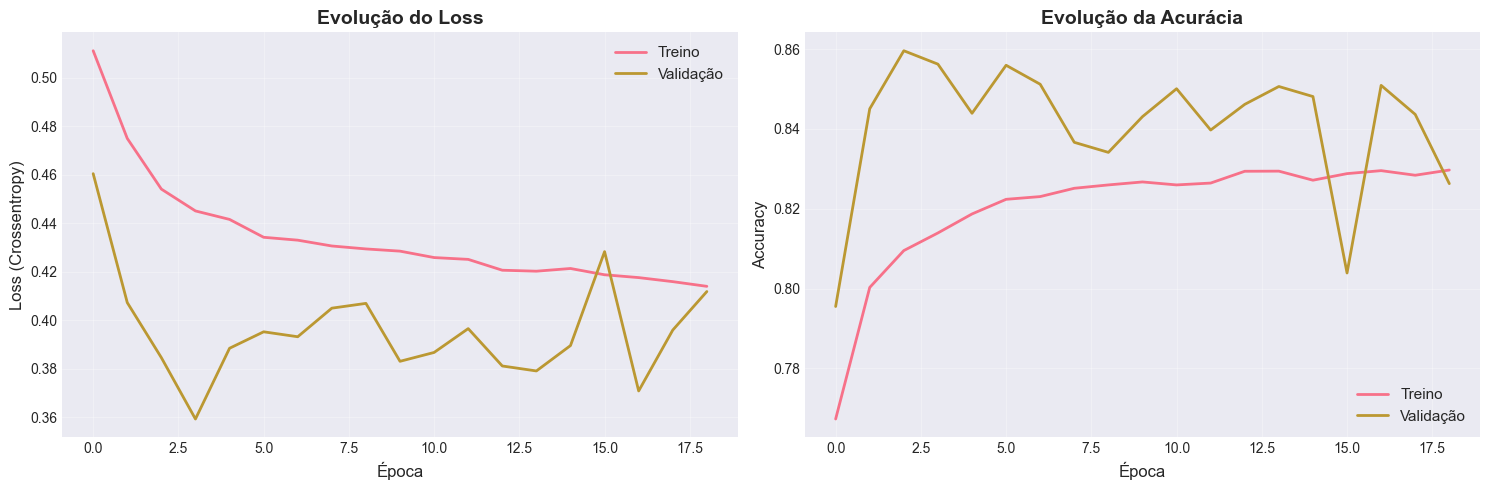


Treinamento parou na época: 19/50
Melhor val_loss (Crossentropy): 0.359365
Melhor val_accuracy: 0.859580


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss (Crossentropy)
axes[0].plot(history.history['loss'], label='Treino', linewidth=2)
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Validação', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss (Crossentropy)', fontsize=12)
axes[0].set_title('Evolução do Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
if 'accuracy' in history.history:
    axes[1].plot(history.history['accuracy'], label='Treino', linewidth=2)
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Evolução da Acurácia', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Informações sobre early stopping
stopped_epoch = len(history.history['loss'])
print(f"\nTreinamento parou na época: {stopped_epoch}/{EPOCHS}")
print(f"Melhor val_loss (Crossentropy): {min(history.history.get('val_loss', [np.nan])):.6f}")
if 'val_accuracy' in history.history:
    print(f"Melhor val_accuracy: {max(history.history['val_accuracy']):.6f}")

## 13. Predições no Conjunto de Teste

Gera as previsões (probabilidades) no conjunto de teste.

In [16]:
print("Gerando predições no conjunto de teste...")

# Agora y_pred terá o shape (N_amostras, 3)
y_pred = model.predict(X_test_seq)

print(f"\n✓ Predições geradas")
print(f"  Shape y_test_seq (Gabarito): {y_test_seq.shape}")
print(f"  Shape y_pred (Probabilidades): {y_pred.shape}")

# Vamos analisar as probabilidades médias previstas para cada classe
print(f"\nProbabilidade média prevista: ")
print(y_pred.mean(axis=0))

Gerando predições no conjunto de teste...
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

✓ Predições geradas
  Shape y_test_seq (Gabarito): (8864,)
  Shape y_pred (Probabilidades): (8864, 1)

Probabilidade média prevista: 
[0.3712951]


## 14. Análise de Performance - Métricas de Volatilidade

          MÉTRICAS DE VOLATILIDADE (BINÁRIO)
277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

🎯 Acurácia: 83.56%

📊 Matriz de Confusão (0=Calmo, 1=Explosão):
[[5741  997]
 [ 460 1666]]

📈 Relatório Detalhado:
              precision    recall  f1-score   support

       Calmo       0.93      0.85      0.89      6738
    Explosão       0.63      0.78      0.70      2126

    accuracy                           0.84      8864
   macro avg       0.78      0.82      0.79      8864
weighted avg       0.85      0.84      0.84      8864



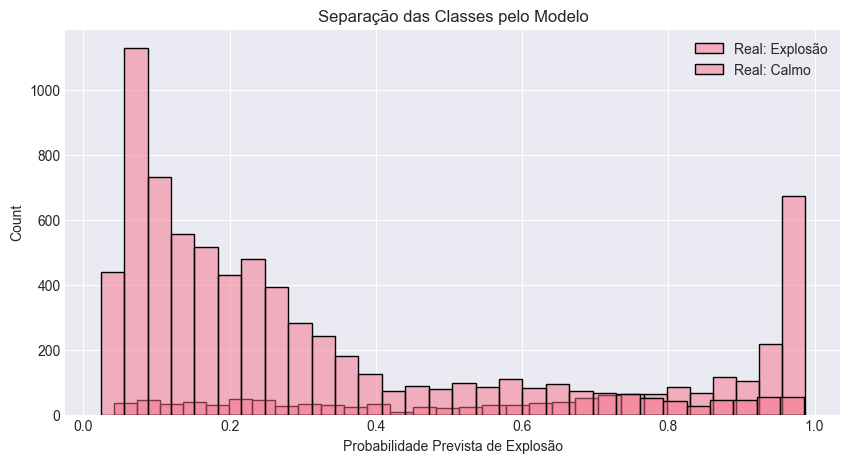

In [17]:
# CÉLULA 13 - AVALIAÇÃO (BINÁRIA)

print("="*60)
print("          MÉTRICAS DE VOLATILIDADE (BINÁRIO)")
print("="*60)

# Previsão (Probabilidade de ser Classe 1 - Explosão)
y_pred_prob = model.predict(X_test_seq) # Shape (N, 1)

# Converter para Classe (0 ou 1) usando limiar de 50%
y_pred_class = (y_pred_prob > 0.5).astype(int).flatten()

# 1. Acurácia
accuracy = accuracy_score(y_test_seq, y_pred_class)
print(f"\n🎯 Acurácia: {accuracy * 100:.2f}%")

# 2. Matriz de Confusão
print("\n📊 Matriz de Confusão (0=Calmo, 1=Explosão):")
print(confusion_matrix(y_test_seq, y_pred_class))

# 3. Relatório
print("\n📈 Relatório Detalhado:")
print(classification_report(y_test_seq, y_pred_class, target_names=['Calmo', 'Explosão'], zero_division=0))

# 4. Gráfico de Confiança
plt.figure(figsize=(10, 5))
sns.histplot(y_pred_prob[y_test_seq==1], color='green', label='Real: Explosão', bins=30, alpha=0.5)
sns.histplot(y_pred_prob[y_test_seq==0], color='red', label='Real: Calmo', bins=30, alpha=0.5)
plt.title('Separação das Classes pelo Modelo')
plt.xlabel('Probabilidade Prevista de Explosão')
plt.legend()
plt.show()

## 15. Análise Visual (Distribuição)

Este gráfico nos mostra se o modelo está "trapaceando" ao chutar apenas a classe dominante (NEUTRO).


--- Análise Visual das Previsões (Classificação) ---


C:\Users\User\AppData\Local\Temp\ipykernel_13308\1288035034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test_seq, palette='viridis', stat='percent', order=[0, 1, 2])
C:\Users\User\AppData\Local\Temp\ipykernel_13308\1288035034.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred_class, palette='plasma', stat='percent', order=[0, 1, 2])


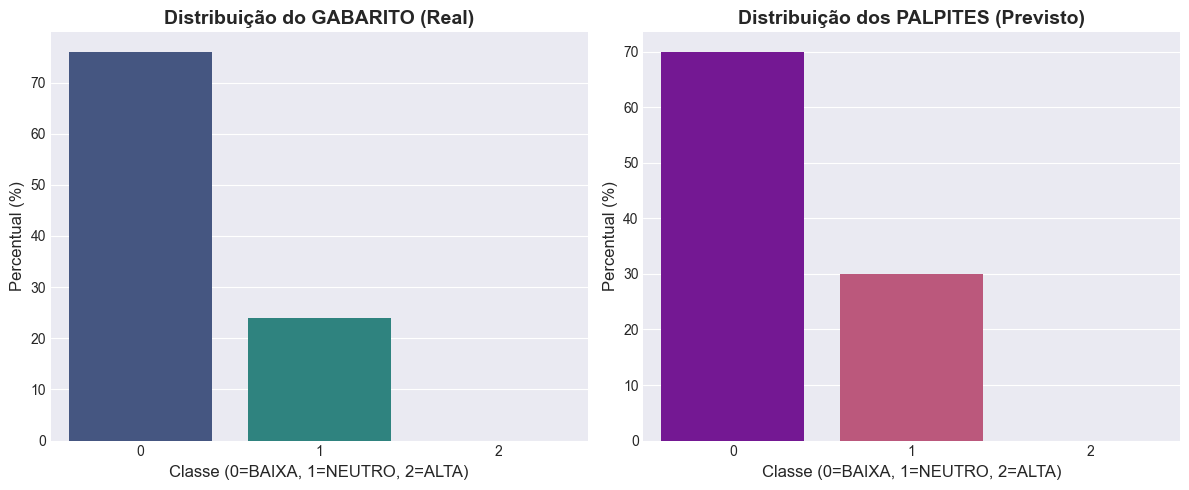


📊 ANÁLISE DO GRÁFICO:
   • Idealmente, o gráfico 'Previsto' deve ter uma distribuição parecida com o 'Real'.
   • Se o 'Previsto' mostrar 100% em uma única classe (ex: NEUTRO),
     significa que o assistente está 'trapaceando' e chutando a classe dominante.


In [18]:
print("\n--- Análise Visual das Previsões (Classificação) ---")

plt.figure(figsize=(12, 5))

# Gráfico 1: Distribuição do Gabarito Real (y_test_seq)
plt.subplot(1, 2, 1)
sns.countplot(x=y_test_seq, palette='viridis', stat='percent', order=[0, 1, 2])
plt.title('Distribuição do GABARITO (Real)', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0=BAIXA, 1=NEUTRO, 2=ALTA)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks([0, 1, 2])

# Gráfico 2: Distribuição dos Palpites (y_pred_class)
plt.subplot(1, 2, 2)
sns.countplot(x=y_pred_class, palette='plasma', stat='percent', order=[0, 1, 2])
plt.title('Distribuição dos PALPITES (Previsto)', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0=BAIXA, 1=NEUTRO, 2=ALTA)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks([0, 1, 2])

plt.tight_layout()
plt.show()

print("\n📊 ANÁLISE DO GRÁFICO:")
print("   • Idealmente, o gráfico 'Previsto' deve ter uma distribuição parecida com o 'Real'.")
print("   • Se o 'Previsto' mostrar 100% em uma única classe (ex: NEUTRO),")
print("     significa que o assistente está 'trapaceando' e chutando a classe dominante.")

## 16. Análise de Confiança

Este gráfico analisa a confiança (probabilidade máxima) do modelo nos seus acertos vs. erros. Queremos que os acertos (verde) tenham confiança maior que os erros (vermelho).


--- Análise de Confiança (Probabilidades) ---


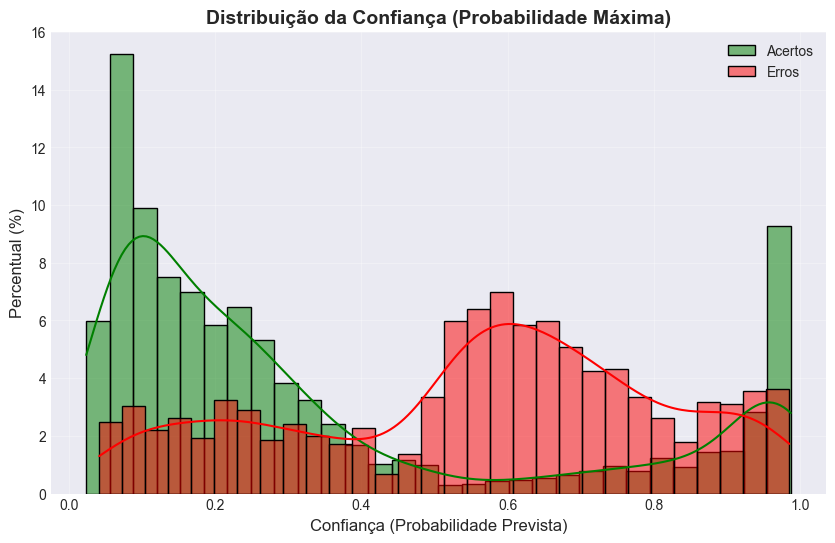


📊 ANÁLISE DO GRÁFICO:
   • Média de Confiança nos Acertos: 33.46%
   • Média de Confiança nos Erros:   55.79%

   • Idealmente, queremos ver o gráfico 'Acertos' (verde) concentrado à direita (alta confiança),
     e o gráfico 'Erros' (vermelho) concentrado à esquerda (baixa confiança).
   • Se os dois gráficos estiverem muito sobrepostos, o modelo não sabe quando está errando.


In [19]:
print("\n--- Análise de Confiança (Probabilidades) ---")

# Pega a maior probabilidade (confiança) de cada previsão
prob_confidence = np.max(y_pred, axis=1)

# Separa a confiança dos acertos e dos erros
correct_predictions_mask = (y_pred_class == y_test_seq)
confidence_acertos = prob_confidence[correct_predictions_mask]
confidence_erros = prob_confidence[~correct_predictions_mask]

plt.figure(figsize=(10, 6))
sns.histplot(confidence_acertos, bins=30, kde=True, color='green', label='Acertos', stat='percent')
sns.histplot(confidence_erros, bins=30, kde=True, color='red', label='Erros', stat='percent')
plt.title('Distribuição da Confiança (Probabilidade Máxima)', fontsize=14, fontweight='bold')
plt.xlabel('Confiança (Probabilidade Prevista)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n📊 ANÁLISE DO GRÁFICO:")
if (len(confidence_acertos) > 0) and (len(confidence_erros) > 0):
    print(f"   • Média de Confiança nos Acertos: {np.mean(confidence_acertos)*100:.2f}%")
    print(f"   • Média de Confiança nos Erros:   {np.mean(confidence_erros)*100:.2f}%")
else:
    print("   • Não foi possível calcular médias (sem acertos ou sem erros).")

print("\n   • Idealmente, queremos ver o gráfico 'Acertos' (verde) concentrado à direita (alta confiança),")
print("     e o gráfico 'Erros' (vermelho) concentrado à esquerda (baixa confiança).")
print("   • Se os dois gráficos estiverem muito sobrepostos, o modelo não sabe quando está errando.")

## 17. Resumo Final e Conclusões

O resumo foca nas métricas de classificação.

In [20]:
# Gerar o relatório de classificação como um dicionário para fácil acesso
report_dict = classification_report(y_test_seq, y_pred_class, target_names=['Classe 0 (BAIXA)', 'Classe 1 (ALTA)'], zero_division=0, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

print("\n" + "="*70)
print(" "*20 + "RESUMO FINAL DA ANÁLISE")
print("="*70)

print(f"\n📋 CONFIGURAÇÃO DO MODELO:")
print(f"  • Ticker: {TICKER}")
print(f"  • Timeframe: {timeframe_str}")
print(f"  • Período: {START_DATE.date()} a {END_DATE.date()}")
print(f"  • Total de candles: {len(df_raw)}")
print(f"  • Lookback: {LOOKBACK}")
print(f"  • LSTM Units: {LSTM_UNITS} (Camada 1), {int(LSTM_UNITS/2)} (Camada 2)")
print(f"  • Features utilizadas: {len(FEATURE_NAMES)}")
print(f"  • Épocas treinadas: {stopped_epoch}/{EPOCHS}")

print(f"\n📊 RESULTADOS DE PERFORMANCE (CLASSIFICAÇÃO):")
print(f"  • 🎯 Acurácia (Nota Final): {accuracy * 100:.2f}%")
print(f"\n  • 📈 Relatório Detalhado:")
print(df_report.to_string(float_format='{:.2f}'.format))

print(f"\n✅ ANÁLISE QUALITATIVA:")
print("  • Acurácia: Mostra a 'nota final' geral. (Idealmente > 33% para 3 classes)")
print("  • Relatório Detalhado: É a parte mais importante. Mostra a capacidade")
print("    do assistente em acertar as classes raras (BAIXA e ALTA).")
print("  • Foco no 'f1-score' das Classes 0 e 2.")


print(f"\n⚠️  CONSIDERAÇÕES:")
# Pega a distribuição real do gabarito de treino
dist_treino = pd.Series(y_train_seq).value_counts(normalize=True).sort_index()
print(f"  • O 'gabarito' é desbalanceado:")
print(f"    Classe 0 (BAIXA): {dist_treino.get(0, 0):.2%}")
print(f"    Classe 1 (NEUTRO): {dist_treino.get(1, 0):.2%}")
print(f"    Classe 2 (ALTA): {dist_treino.get(2, 0):.2%}")
print(f"  • O 'class_weight' (Célula 9) foi aplicado para forçar o modelo")
print(f"    a aprender os padrões das classes raras (0 e 2).")

print("\n" + "="*70 + "\n")


                    RESUMO FINAL DA ANÁLISE

📋 CONFIGURAÇÃO DO MODELO:
  • Ticker: WDO$
  • Timeframe: M15
  • Período: 2021-01-01 a 2025-10-31
  • Total de candles: 44804
  • Lookback: 96
  • LSTM Units: 64 (Camada 1), 32 (Camada 2)
  • Features utilizadas: 22
  • Épocas treinadas: 19/50

📊 RESULTADOS DE PERFORMANCE (CLASSIFICAÇÃO):
  • 🎯 Acurácia (Nota Final): 83.56%

  • 📈 Relatório Detalhado:
                  precision  recall  f1-score  support
Classe 0 (BAIXA)       0.93    0.85      0.89  6738.00
Classe 1 (ALTA)        0.63    0.78      0.70  2126.00
accuracy               0.84    0.84      0.84     0.84
macro avg              0.78    0.82      0.79  8864.00
weighted avg           0.85    0.84      0.84  8864.00

✅ ANÁLISE QUALITATIVA:
  • Acurácia: Mostra a 'nota final' geral. (Idealmente > 33% para 3 classes)
  • Relatório Detalhado: É a parte mais importante. Mostra a capacidade
    do assistente em acertar as classes raras (BAIXA e ALTA).
  • Foco no 'f1-score' das Classes

      OTIMIZAÇÃO DE RÉGUA (THRESHOLD) & BACKTEST SIMULADO

Simulando operações com Payoff: Win 2.0 / Loss -1.0...



,Régua (Prob),Precisão (Win Rate),Recall (Oportunidades),Trades Feitos,Wins,Losses,Resultado (R)
0,0.50,62.6%,78.4%,2663,1666,997,2335.000000
1,0.55,65.6%,76.6%,2483,1629,854,2404.000000
2,0.60,69.4%,74.6%,2286,1586,700,2472.000000
3,0.65,73.1%,71.8%,2090,1527,563,2491.000000
4,0.70,76.7%,68.5%,1899,1457,442,2472.000000
5,0.75,80.2%,63.9%,1695,1359,336,2382.000000
6,0.80,83.2%,59.3%,1516,1261,255,2267.000000
7,0.85,84.6%,53.0%,1332,1127,205,2049.000000
8,0.90,87.7%,45.3%,1099,964,135,1793.000000
9,0.95,92.5%,35.1%,808,747,61,1433.000000


C:\Users\User\AppData\Local\Temp\ipykernel_13308\1625394891.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Régua (Prob)', y='Resultado', palette='viridis')


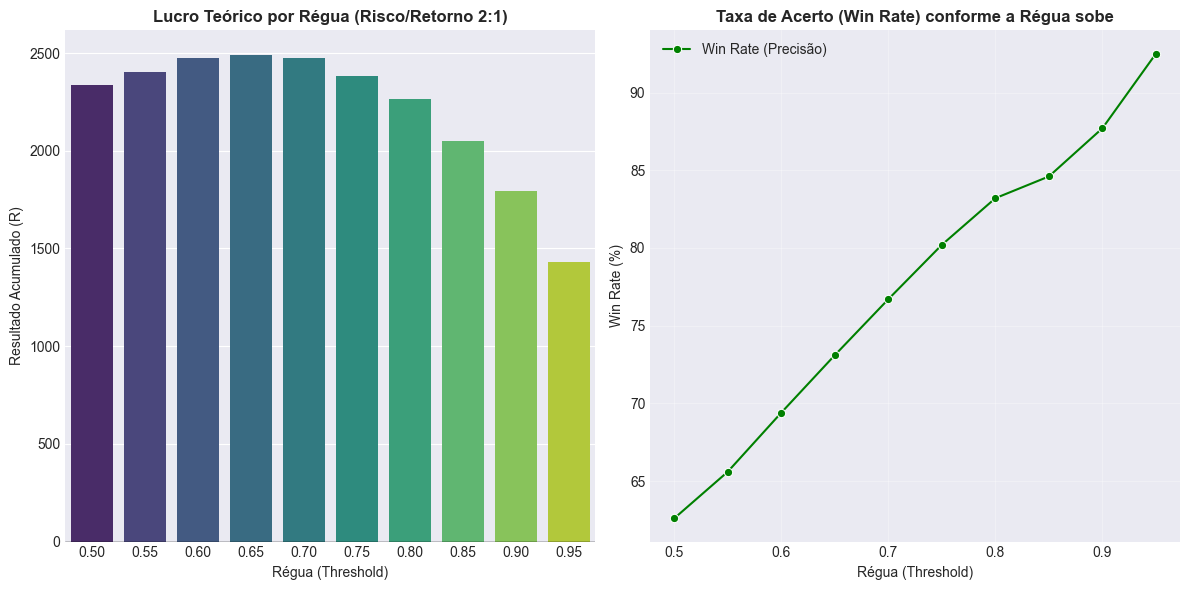


🏆 MELHOR CONFIGURAÇÃO SUGERIDA:
   Régua: > 0.65
   Resultado Projetado: 2491.0R
   Win Rate Esperado: 73.1%


In [21]:
# CÉLULA 18 - OTIMIZAÇÃO DE THRESHOLD (RÉGUA) COM SIMULAÇÃO

import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("      OTIMIZAÇÃO DE RÉGUA (THRESHOLD) & BACKTEST SIMULADO")
print("="*60)

# 1. Definir Cenário Financeiro para Simulação
# Exemplo: Quando o mercado explode (Acerto), ganhamos em média 2.0x o risco.
# Quando o mercado fica calmo e entramos errado (Alarme Falso), perdemos 1.0x o risco.
AVG_WIN = 2.0  # Ganho médio em uma explosão correta (em R ou pontos)
AVG_LOSS = -1.0 # Perda média em um alarme falso (Stop em mercado lateral)

thresholds = np.arange(0.50, 0.96, 0.05)
results = []

print(f"\nSimulando operações com Payoff: Win {AVG_WIN} / Loss {AVG_LOSS}...\n")

for thresh in thresholds:
    # Aplicar a régua
    y_class_opt = (y_pred_prob > thresh).astype(int).flatten()
    
    # Calcular métricas técnicas
    precision = precision_score(y_test_seq, y_class_opt, zero_division=0)
    recall = recall_score(y_test_seq, y_class_opt, zero_division=0)
    
    # Calcular métricas financeiras (Simulação)
    # Trades: Quantas vezes o modelo disse "ENTRA!" (Classe 1)
    total_trades = np.sum(y_class_opt == 1)
    
    # Wins: Quantas vezes ele disse "ENTRA" e era realmente Explosão (1)
    winning_trades = np.sum((y_class_opt == 1) & (y_test_seq == 1))
    
    # Losses: Quantas vezes ele disse "ENTRA" e era Calmo (0)
    losing_trades = np.sum((y_class_opt == 1) & (y_test_seq == 0))
    
    # Resultado Financeiro Teórico (em unidades de Risco)
    total_return = (winning_trades * AVG_WIN) + (losing_trades * AVG_LOSS)
    
    results.append({
        'Régua (Prob)': f"{thresh:.2f}",
        'Precisão (Win Rate)': f"{precision*100:.1f}%",
        'Recall (Oportunidades)': f"{recall*100:.1f}%",
        'Trades Feitos': total_trades,
        'Wins': winning_trades,
        'Losses': losing_trades,
        'Resultado (R)': total_return
    })

# Criar DataFrame e Exibir
df_opt = pd.DataFrame(results)

# Converter Resultado para numérico para colorir
df_style = df_opt.style.background_gradient(subset=['Resultado (R)'], cmap='RdYlGn')
display(df_style)

# --- GRÁFICO DE COMPARAÇÃO ---
plt.figure(figsize=(12, 6))

# Converter de volta para float para plotagem
df_plot = df_opt.copy()
df_plot['Threshold'] = thresholds
df_plot['Resultado'] = df_plot['Resultado (R)'].astype(float)
df_plot['Win Rate'] = df_plot['Precisão (Win Rate)'].str.rstrip('%').astype(float)

# Plot 1: Resultado Financeiro
plt.subplot(1, 2, 1)
sns.barplot(data=df_plot, x='Régua (Prob)', y='Resultado', palette='viridis')
plt.title('Lucro Teórico por Régua (Risco/Retorno 2:1)', fontsize=12, fontweight='bold')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Resultado Acumulado (R)', fontsize=10)
plt.xlabel('Régua (Threshold)', fontsize=10)

# Plot 2: Trade-off Precisão vs Trades
plt.subplot(1, 2, 2)
sns.lineplot(data=df_plot, x='Threshold', y='Win Rate', marker='o', label='Win Rate (Precisão)', color='green')
plt.title('Taxa de Acerto (Win Rate) conforme a Régua sobe', fontsize=12, fontweight='bold')
plt.xlabel('Régua (Threshold)', fontsize=10)
plt.ylabel('Win Rate (%)', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Melhor cenário
best_row = df_plot.loc[df_plot['Resultado'].idxmax()]
print(f"\n🏆 MELHOR CONFIGURAÇÃO SUGERIDA:")
print(f"   Régua: > {best_row['Régua (Prob)']}")
print(f"   Resultado Projetado: {best_row['Resultado']}R")
print(f"   Win Rate Esperado: {best_row['Precisão (Win Rate)']}")

In [23]:
# CÉLULA 20 - VALIDAÇÃO INTEGRADA (SIMULAÇÃO DE PRODUÇÃO)
# Esta célula utiliza as classes do projeto 'src' para garantir que o ambiente de
# produção (arquivos .py) está reproduzindo exatamente o resultado da pesquisa.

import sys
import os
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Configurar Caminhos (Adiciona a raiz do projeto ao Python Path)
# Assume que o notebook está em notebooks/analyzes/
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Diretório do Projeto: {project_root}")

# 2. Importar a Estratégia do Projeto
try:
    from src.strategies.lstm_volatility import LSTMVolatilityStrategy
    print("✅ Classe LSTMVolatilityStrategy importada com sucesso.")
except ImportError as e:
    print(f"❌ Erro ao importar estratégia: {e}")
    # Fallback para depuração se necessário
    # from src.strategies.lstm import LSTMWrapper 

# 3. Configuração de Teste
ASSET = "WDO$"
MODEL_PATH_PREFIX = project_root / "models" / f"{ASSET}_LSTMVolatilityStrategy_prod"
START_OOS = "2025-11-01"
END_OOS = "2025-11-18" # Ajuste conforme os dados disponíveis
BEST_THRESHOLD = 0.70  # A régua definida na análise anterior

print(f"Carregando modelo de: {MODEL_PATH_PREFIX}...")

# 4. Instanciar e Carregar a Estratégia
# Inicializa com parâmetros padrão (serão sobrescritos pelo load ou usados na feature generation)
strategy = LSTMVolatilityStrategy(
    lookback=96, 
    target_period=5, 
    volatility_multiplier=3.0
)

# Carrega o modelo treinado (Keras) e o Scaler (Joblib)
try:
    # O método load deve retornar o objeto wrapper pronto para uso
    model_wrapper = strategy.load(str(MODEL_PATH_PREFIX))
    print("✅ Modelo e Scaler carregados do disco com sucesso.")
except Exception as e:
    print(f"❌ Falha ao carregar modelo: {e}")
    raise

# 5. Preparar Dados (Usando lógica do Projeto)
# Reutilizamos o df_oos_raw que já baixamos na célula anterior para garantir consistência
# Mas passamos pelo pipeline da CLASSE da estratégia
print("Gerando features via Classe da Estratégia...")
df_prod_features = strategy.define_features(df_raw)

# Recriar o Target (apenas para aferir acurácia, na produção real isso não existe)
df_prod_clean = strategy.define_target(df_prod_features) 

# Filtrar período de validação
df_prod_final = df_prod_clean[df_prod_clean.index >= pd.Timestamp(START_OOS).tz_localize("UTC")]
print(f"Dados prontos para inferência: {len(df_prod_final)} candles.")

# 6. Executar Inferência (Simulando Produção)
# Separar X (Features)
feature_cols = strategy.get_feature_names()
X_prod = df_prod_final[feature_cols].values
y_true_prod = df_prod_final['target'].values

# A mágica acontece aqui: O wrapper deve usar o scaler CARREGADO, não um novo
print("Executando predição (usando scaler e modelo salvos)...")
try:
    # O método predict do wrapper deve lidar com a criação de sequências e scaling
    # Nota: Dependendo da implementação do LSTMWrapper, ele pode retornar classes ou probs
    # Vamos assumir que retorna probabilidades ou classes diretas.
    # Se o seu wrapper retorna classes (0/1) com threshold 0.5 fixo, precisamos acessar o modelo interno
    # para aplicar nosso threshold de 0.70.
    
    # Acessando probabilidades brutas (se implementado no wrapper, senão acessa o keras direto)
    if hasattr(model_wrapper, 'predict_proba'):
        y_probs = model_wrapper.predict_proba(X_prod)
    else:
        # Fallback: Acesso direto ao modelo Keras interno e Scaler
        # Isso replica o que o wrapper faz internamente
        scaler = model_wrapper.scaler
        keras_model = model_wrapper.model
        lookback = model_wrapper.lookback
        
        X_scaled = scaler.transform(X_prod)
        
        # Função auxiliar local para sequências (caso não esteja exposta)
        from src.strategies.lstm import create_sequences # Ajuste o import conforme necessário
        X_seq, y_seq_dummy = create_sequences(X_scaled, np.zeros(len(X_scaled)), lookback)
        
        # Predição Keras
        y_probs = keras_model.predict(X_seq, verbose=0)
        
        # Alinhar y_true (cortar o lookback inicial)
        y_true_aligned = y_true_prod[lookback:]
        
    # Aplicar a Régua Otimizada
    y_pred_class_prod = (y_probs > BEST_THRESHOLD).astype(int).flatten()
    
    # Se y_probs for menor que y_true (devido ao lookback), ajustamos y_true
    if len(y_pred_class_prod) < len(y_true_prod):
        y_true_aligned = y_true_prod[-len(y_pred_class_prod):]
    else:
        y_true_aligned = y_true_prod

    # 7. Relatório de Validação de Produção
    print("\n" + "="*60)
    print(f"🏆 RESULTADO DA VALIDAÇÃO DE PRODUÇÃO (STRATEGY CLASS)")
    print("="*60)
    
    print("\n📊 Matriz de Confusão (Validando implementação):")
    print(confusion_matrix(y_true_aligned, y_pred_class_prod))
    
    print("\n📈 Relatório Detalhado:")
    print(classification_report(y_true_aligned, y_pred_class_prod, target_names=['Calmo', 'Explosão'], zero_division=0))
    
    # Verificação de Sanidade
    # Se este resultado for muito diferente do teste anterior (Célula 19), 
    # significa que a implementação em src/strategies/ tem bugs ou divergências.
    
except Exception as e:
    print(f"❌ Erro durante a inferência: {e}")
    import traceback
    traceback.print_exc()

2025-11-19 19:17:20,961 - INFO - LSTMVolatilityStrategy: Carregando modelo de c:\projects\wtnps-trade\models\WDO$_LSTMVolatilityStrategy_prod
c:\Users\User\AppData\Local\pypoetry\Cache\virtualenvs\wtnps-trade-VyqtAXyS-py3.12\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-11-19 19:17:21,099 - INFO - Modelo carregado de c:\projects\wtnps-trade\models\WDO$_LSTMVolatilityStrategy_prod_lstm.keras, scaler de c:\projects\wtnps-trade\models\WDO$_LSTMVolatilityStrategy_prod_scaler.joblib, params de c:\projects\wtnps-trade\models\WDO$_LSTMVolatilityStrategy_prod_params.joblib


Diretório do Projeto: c:\projects\wtnps-trade
✅ Classe LSTMVolatilityStrategy importada com sucesso.
Carregando modelo de: c:\projects\wtnps-trade\models\WDO$_LSTMVolatilityStrategy_prod...
✅ Modelo e Scaler carregados do disco com sucesso.
Gerando features via Classe da Estratégia...
Dados prontos para inferência: 0 candles.


KeyError: "None of [Index(['retorno', 'gap', 'roc_3', 'roc_8', 'retorno_relativo', 'ema_9',\n       'sma_20', 'sma_200', 'dist_ema_9', 'dist_sma_20', 'dist_sma_200', 'rsi',\n       'band_width', 'atr_norm', 'body_rel', 'upper_shad_rel',\n       'lower_shad_rel', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',\n       'volume'],\n      dtype='object', name='time')] are in the [index]"